## Visualize Cell Types (CT) by Cell Type Annotation Tool (CTann)

Here, we build the histogram below for:
- Heart
- Lung
- Pancreas

![](images/goal_vis.png)

## Install and import libraries

In [1]:
%pip install requests pandas seaborn matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


Note: you may need to restart the kernel to use updated packages.


## Load data

In [2]:
# Make sure the data folder is present
folder_path = 'data'
file_name = 'sc-transcriptomics-cell-instances.csv.gz'

if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_path}' created.")
else:
    print(f"Folder '{folder_path}' already exists.")

# Define the path to the file. 
file_path = f'{folder_path}/{file_name}'

# Check if the file exists
if not os.path.exists(file_path):
    # If the file doesn't exist, run the curl command
    !curl -L https://cdn.humanatlas.io/temp/sc-transcriptomics-cell-instances.csv.gz -o {file_path}
    print(f'File downloaded and saved at {file_path}')
else:
    print(f'File already exists at {file_path}')

Folder 'data' already exists.
File already exists at data/sc-transcriptomics-cell-instances.csv.gz


## Preprocess data

In [3]:
dtype_dict = {
    'organ': 'str',
    'tool': 'category',
    'cell': 'str',
    'confidence_score': 'float32'
}

df = pd.read_csv(
  file_path, 
  compression='gzip',
  dtype=dtype_dict, 
  usecols=dtype_dict.keys(), 
  nrows=20000000
  )
df

,organ,tool,cell,confidence_score
0,UBERON:0002106,popv,AAACCCAAGCAGGCAT,1.000000
1,UBERON:0002106,popv,AAACCCAAGGCCCACT,1.000000
2,UBERON:0002106,popv,AAACCCAAGGTACAAT,1.000000
3,UBERON:0002106,popv,AAACCCAAGTATGGCG,1.000000
4,UBERON:0002106,popv,AAACCCACAGTAGAAT,1.000000
...,...,...,...,...
19999995,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCATCCTGTA,0.690222
19999996,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCCCTAATCC,0.599298
19999997,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCCCTCCTGA,0.675584
19999998,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCCTAAGGTC,0.849783


In [4]:
df['tool'] = df['tool'].astype('category')

df_filtered = df[df['tool'] != 'panhuman']
df_filtered['tool'] = df_filtered['tool'].cat.remove_unused_categories()
# df_filtered = df
df_filtered

C:\Users\abueckle\AppData\Local\Temp\1\ipykernel_74408\602226207.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['tool'] = df_filtered['tool'].cat.remove_unused_categories()


,organ,tool,cell,confidence_score
0,UBERON:0002106,popv,AAACCCAAGCAGGCAT,1.000000
1,UBERON:0002106,popv,AAACCCAAGGCCCACT,1.000000
2,UBERON:0002106,popv,AAACCCAAGGTACAAT,1.000000
3,UBERON:0002106,popv,AAACCCAAGTATGGCG,1.000000
4,UBERON:0002106,popv,AAACCCACAGTAGAAT,1.000000
...,...,...,...,...
19999995,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCATCCTGTA,0.690222
19999996,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCCCTAATCC,0.599298
19999997,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCCCTCCTGA,0.675584
19999998,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCCTAAGGTC,0.849783


## Create 3 `df`s for organs

In [5]:
organ_look_up = {
    'pancreas': 'UBERON:0001264',
    'heart': 'UBERON:0000948',
    'lung': 'UBERON:0002048'
}

In [6]:
df_pancreas = df_filtered[df['organ'] == organ_look_up['pancreas']]
df_pancreas

C:\Users\abueckle\AppData\Local\Temp\1\ipykernel_74408\2652115666.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_pancreas = df_filtered[df['organ'] == organ_look_up['pancreas']]


,organ,tool,cell,confidence_score


In [7]:
df_heart = df_filtered[df['organ'] == organ_look_up['heart']]
df_heart

C:\Users\abueckle\AppData\Local\Temp\1\ipykernel_74408\334844182.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_heart = df_filtered[df['organ'] == organ_look_up['heart']]


,organ,tool,cell,confidence_score
61353,UBERON:0000948,azimuth,AACGCGCAGAAAGCCTACGAAATGCTAGTCAAACCATAGT,0.524065
61354,UBERON:0000948,azimuth,AACGCGCAGAAAGCCTACGAAATGCTAGTCAATACCGAAT,0.406929
61355,UBERON:0000948,azimuth,AACGCGCAGAAAGCCTACGAAATGCTAGTCACAATGCTAT,0.795150
61356,UBERON:0000948,azimuth,AACGCGCAGAAAGCCTACGAAATGCTAGTCACATGGTAAT,0.251713
61357,UBERON:0000948,azimuth,AACGCGCAGAAAGCCTACGAAATGCTAGTCACCGGTTCT,0.763177
...,...,...,...,...
18312265,UBERON:0000948,popv,TTTGTGGCATGTTGCA,1.000000
18312266,UBERON:0000948,popv,TTTGTGTTCAATCTCT,1.000000
18312267,UBERON:0000948,popv,TTTGTGTTCCGGGACT,1.000000
18312268,UBERON:0000948,popv,TTTGTGTTCCTGTTCA,1.000000


In [8]:
df_lung = df_filtered[df['organ'] == organ_look_up['lung']]
df_lung

C:\Users\abueckle\AppData\Local\Temp\1\ipykernel_74408\1387838084.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_lung = df_filtered[df['organ'] == organ_look_up['lung']]


,organ,tool,cell,confidence_score
613615,UBERON:0002048,azimuth,AAACCCAAGAAGAGCA,0.910813
613616,UBERON:0002048,azimuth,AAACCCAAGCCGTTGC,0.765011
613617,UBERON:0002048,azimuth,AAACCCACACACCTAA,0.723945
613618,UBERON:0002048,azimuth,AAACCCACAGTTACCA,0.826277
613619,UBERON:0002048,azimuth,AAACCCAGTCAAATCC,0.496508
...,...,...,...,...
19999995,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCATCCTGTA,0.690222
19999996,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCCCTAATCC,0.599298
19999997,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCCCTCCTGA,0.675584
19999998,UBERON:0002048,azimuth,TCCGTCTAAATCCGTCCTAAGGTC,0.849783


## Visualize

In [9]:
sns.set_theme(rc={'figure.figsize': (16,8)})

plt.rcParams.update({'font.size': 14,  # Controls default text size
                     'axes.labelsize': 12,  # Controls axes label size
                     'xtick.labelsize': 10,  # Controls x-axis tick label size
                     'ytick.labelsize': 10,  # Controls y-axis tick label size
                     'legend.fontsize': 12})  # Controls legend font size

Text(0, 0.5, '# of Cells')

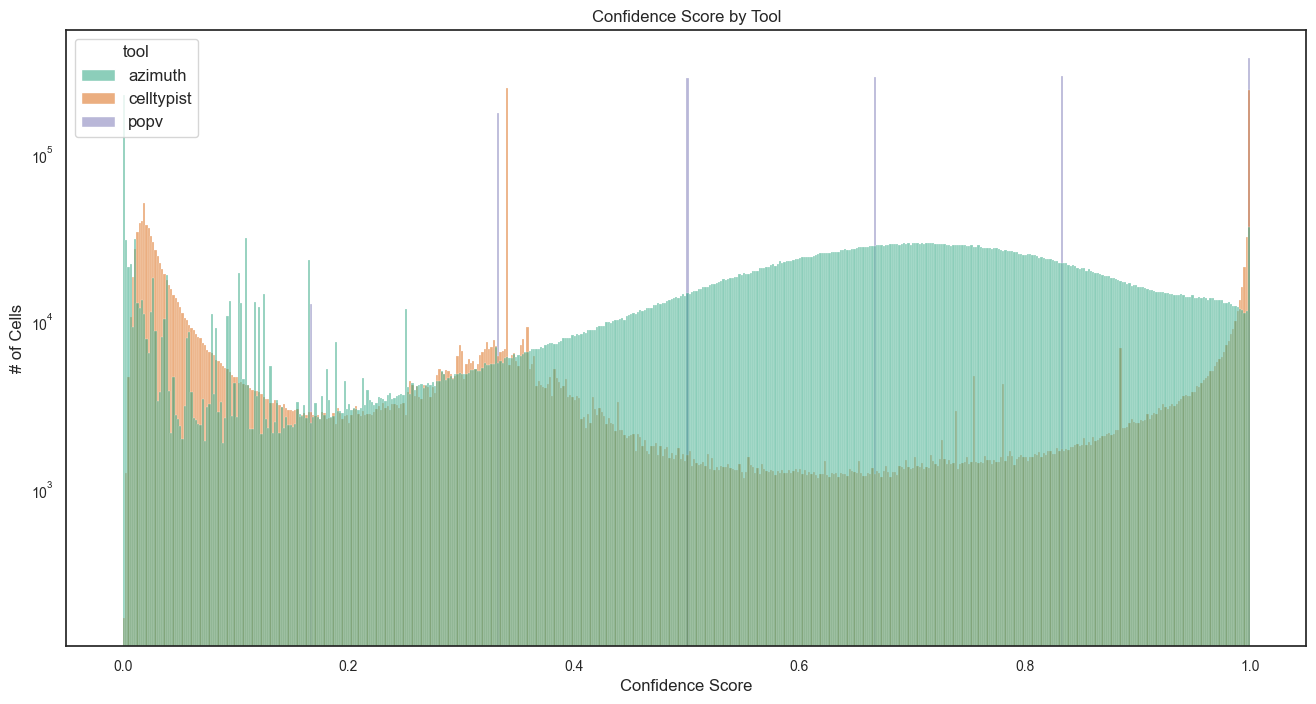

In [11]:
# make plot
g = sns.histplot(
  data=df_filtered, 
  x="confidence_score",
  binwidth=.002, 
  hue='tool',
  palette="Dark2"
  )

# Set the style to white
sns.set_style('white')

# adjust scales
plt.yscale('log')

# adjust labels++
plt.title('Confidence Score by Tool')
plt.xlabel('Confidence Score')
plt.ylabel('# of Cells')